### 4.6 RBA Policy Classifier: seven readings of one decision

[![content: AI-generated](../_static/badges/ai-generated.svg)](ai-acknowledgement) [![content: human-reviewed & edited](../_static/badges/human-reviewed-edited.svg)](ai-acknowledgement)

$$\text{action} = \begin{cases}\text{cut} & \hat y < 2.0 \\ \text{hike} & \hat y > 3.0 \\
\text{hold} & \text{otherwise}\end{cases}$$

$$i^{*} = r^{*} + \pi + \varphi_\pi(\pi-2.5) + \varphi_u\,\Delta u_{t-1}$$

$$P(Y\le j) = F(\theta_j - x'\beta)$$

left to right: the transparent **threshold** baseline (reportable, macro-F1 0.775); the
**Taylor rule** (fixed and estimated variants); **ordered logit/probit** ($F$ = logistic or
$\Phi$). Frank–Hall XGBoost decomposes the same ordinal target into $K{-}1$ cumulative
binary classifiers; majority vote takes the mode of the first four, tie-broken by
threshold's own call.

*Source: `src/models/rba_classifier.py`, served at `GET /rba-action`*

In [4]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

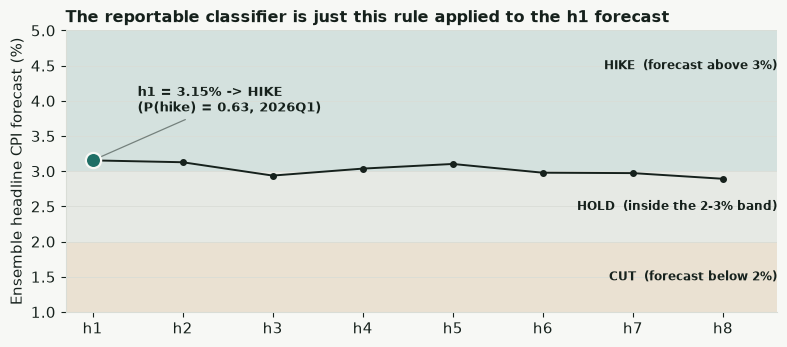

In [5]:
fc = pd.read_csv(TABLEAU / "forecast.csv")
fc = fc[(fc["model_family"] == "ensemble") & (fc["target"] == "Headline")].sort_values("horizon")
rba = pd.read_csv(TABLEAU / "rba_action.csv")
thr = rba[rba["model"] == "threshold"].iloc[0]

fig, ax = plt.subplots(figsize=(8.0, 3.6))
lo, hi = 1.0, 5.0
ax.axhspan(lo, 2.0, color=HIGHLIGHT, alpha=0.16, linewidth=0)
ax.axhspan(2.0, 3.0, color=GRID, alpha=0.55, linewidth=0)
ax.axhspan(3.0, hi, color=ACCENT, alpha=0.16, linewidth=0)
for y, text in ((1.5, "CUT  (forecast below 2%)"), (2.5, "HOLD  (inside the 2-3% band)"), (4.5, "HIKE  (forecast above 3%)")):
    ax.text(8.6, y, text, ha="right", va="center", fontsize=8.8, fontweight="bold")
ax.plot(fc["horizon"], fc["forecast"], color=INK, linewidth=1.4, marker="o", markersize=4)
h1 = fc.iloc[0]
ax.scatter([1], [h1["forecast"]], s=120, color=ACCENT, edgecolor=PAPER, linewidth=1.6, zorder=4)
ax.annotate(f"h1 = {h1['forecast']:.2f}% -> {thr['predicted_action'].upper()}\n(P(hike) = {thr['confidence']:.2f}, "
            f"{thr['target_quarter']})", (1, h1["forecast"]), xytext=(1.5, 3.85), fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=INK, alpha=0.5, lw=0.9))
ax.set_ylim(lo, hi)
ax.set_xlim(0.7, 8.6)
ax.set_xticks(fc["horizon"], [f"h{h}" for h in fc["horizon"]])
ax.set_ylabel("Ensemble headline CPI forecast (%)")
ax.set_title("The reportable classifier is just this rule applied to the h1 forecast", loc="left",
             fontsize=11.5, fontweight="bold")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

The threshold rule is the one the project reports, but it's just one of seven readings of the same decision. The chart below scores all seven on the 41 test quarters (left, higher is better) and shows what the models that produce probabilities expect for the next quarter (right):

{glue:}`/00_results_at_a_glance.ipynb::rba_models_fig`

Only four of the seven models produce probabilities, so only those appear on the right. The same chart is on the [Key Findings](../00_results_at_a_glance) page.

#### Explained, step by step

**1. The threshold baseline (the reportable model)**

$$\text{action} = \begin{cases}\text{cut} & \hat y < 2.0 \\ \text{hike} & \hat y > 3.0 \\ \text{hold} & \text{otherwise}\end{cases}$$

The simplest possible classifier: check which side of the RBA's own 2-3% target band the headline CPI forecast $\hat y$ falls on. Below the band $\to$ room to cut; above $\to$ pressure to hike; inside $\to$ hold. No fitted parameters, just the RBA's published target range wired into a rule. It's also the one that's actually reportable (macro-F1 = 0.775), beating every fitted alternative below.

**2. Taylor rule**

$$i^{*} = r^{*} + \pi + \varphi_\pi(\pi-2.5) + \varphi_u\,\Delta u_{t-1}$$

A classic monetary-policy formula for a "textbook" target interest rate $i^*$. $r^*$ is the assumed neutral real interest rate; adding current inflation $\pi$ converts it to a nominal rate. $\varphi_\pi(\pi - 2.5)$ is a correction: if inflation is above the 2.5% target midpoint, this term is positive and pushes $i^*$ up (tighten); if below, it pushes $i^*$ down. $\varphi_u\,\Delta u_{t-1}$ adds a reaction to last quarter's *change* in unemployment: rising unemployment typically pushes the prescribed rate down. $\varphi_\pi$ and $\varphi_u$ are sensitivity coefficients, either fixed at textbook values or estimated from the data (the app's two Taylor-rule variants).

**3. Ordered logit / probit**

$$P(Y\le j) = F(\theta_j - x'\beta)$$

These treat the three outcomes (cut < hold < hike) as **ordered**, not just three unrelated labels. The model knows "hike" is "further" from "cut" than "hold" is. $x'\beta$ is a linear combination of predictors; $\theta_j$ are estimated **cutpoints** on that underlying score scale; $F$ converts the raw score into a probability between 0 and 1: the logistic CDF for **ordered logit**, or $\Phi$, the standard normal CDF, for **ordered probit**. The formula reads: "the probability the outcome is category $j$ or lower equals the probability the underlying score $x'\beta$, plus noise, falls below cutpoint $\theta_j$." Subtracting consecutive cumulative probabilities gives each individual class's probability.

The remaining models (Frank-Hall XGBoost and the majority vote, both described above) combine these same probability outputs differently rather than introducing new formulas.

How well does that simple rule do against the fitted alternatives on the same 41 walk-forward test quarters? Left: where the threshold rule's calls land. Right: its macro-F1 lead over each rival, with a paired-bootstrap 95% interval.

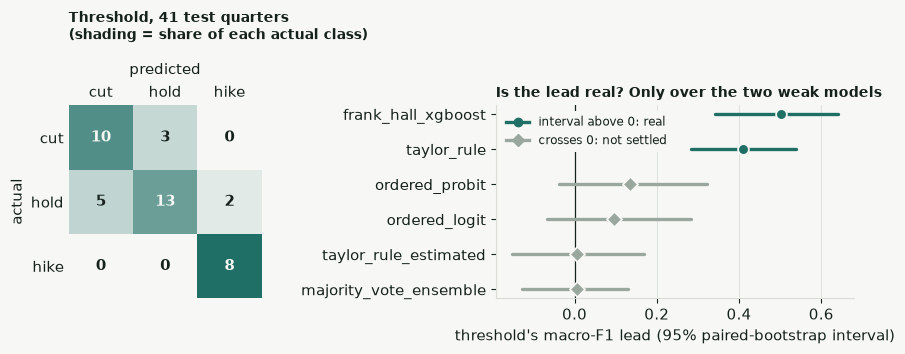

In [6]:
REPORT = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text().splitlines()

def md_table(after_line_startswith):
    """Rows of the first markdown table that follows the line starting with the given text."""
    start = next(i for i, l in enumerate(REPORT) if l.startswith(after_line_startswith))
    first = next(i for i in range(start, len(REPORT)) if REPORT[i].startswith("|"))
    rows = []
    for l in REPORT[first:]:
        if not l.startswith("|"):
            break
        rows.append([c.strip() for c in l.strip("|").split("|")])
    return pd.DataFrame(rows[2:], columns=rows[0])

conf = md_table("### threshold").set_index("actual").astype(int)
gaps = md_table("## Small-Sample Caveat")
gaps["gap"] = gaps["gap"].str.replace("threshold - ", "", regex=False)
gaps["observed"] = gaps["observed_macro_f1_gap"].astype(float)
ci = gaps["paired_bootstrap_95pct_ci"].str.extract(r"\[(-?[\d.]+), (-?[\d.]+)\]").astype(float)
gaps["lo"], gaps["hi"] = ci[0], ci[1]
gaps = gaps.sort_values("observed").reset_index(drop=True)

fig, (a, b) = plt.subplots(1, 2, figsize=(9.0, 3.7), gridspec_kw={"width_ratios": [1, 1.5]})
classes = ["cut", "hold", "hike"]
m = conf.loc[classes, classes].to_numpy()
a.imshow(m / m.sum(axis=1, keepdims=True), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("t", [PAPER, ACCENT]),
         vmin=0, vmax=1)
for (i, j), v in np.ndenumerate(m):
    a.text(j, i, str(v), ha="center", va="center", fontsize=11, fontweight="bold",
           color=PAPER if m[i, j] / m[i].sum() > 0.55 else INK)
a.set_xticks(range(3), classes)
a.set_yticks(range(3), classes)
a.set_xlabel("predicted", labelpad=8)
a.set_ylabel("actual")
a.xaxis.set_label_position("top")
a.xaxis.tick_top()
a.grid(False)
a.tick_params(length=0)
for s in a.spines.values():
    s.set_visible(False)
a.set_title("Threshold, 41 test quarters\n(shading = share of each actual class)", loc="left", fontsize=10, fontweight="bold", y=1.3)

y = np.arange(len(gaps))
b.axvline(0, color=INK, linewidth=0.9)
for yi, r in gaps.iterrows():
    settled = r["lo"] > 0
    b.plot([r["lo"], r["hi"]], [yi, yi], color=ACCENT if settled else MUTED, linewidth=2.4, solid_capstyle="round")
    b.scatter([r["observed"]], [yi], s=60, color=ACCENT if settled else MUTED, edgecolor=PAPER, linewidth=1.3, zorder=3,
              marker="o" if settled else "D")
b.set_yticks(y, gaps["gap"])
b.set_xlabel("threshold's macro-F1 lead (95% paired-bootstrap interval)")
b.set_title("Is the lead real? Only over the two weak models", loc="left", fontsize=10, fontweight="bold")
from matplotlib.lines import Line2D
b.legend(handles=[Line2D([], [], color=ACCENT, marker="o", linewidth=2.4, label="interval above 0: real"),
                  Line2D([], [], color=MUTED, marker="D", linewidth=2.4, label="crosses 0: not settled")],
         frameon=True, facecolor=PAPER, edgecolor="none", framealpha=1.0, fontsize=8.3, loc="upper left")
b.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Why headline CPI, not trimmed mean, drives the rule.** The threshold rule applies the RBA's published 2–3% target band,
which is a band for CPI inflation, so it takes the headline forecast. Trimmed mean, the underlying measure described in
[§1](../01_business_understanding), is not ignored: ordered logit, ordered probit and Frank–Hall XGBoost all receive it as a
feature. As a check, the same rule was run on the trimmed-mean forecast over the same 41 test quarters:

41 test quarters (2014Q1 to 2024Q1); headline rule reproduces the reported macro-F1 0.775; the two inputs disagree in 15 quarters; the trimmed-mean forecast is 0.14pp lower on average


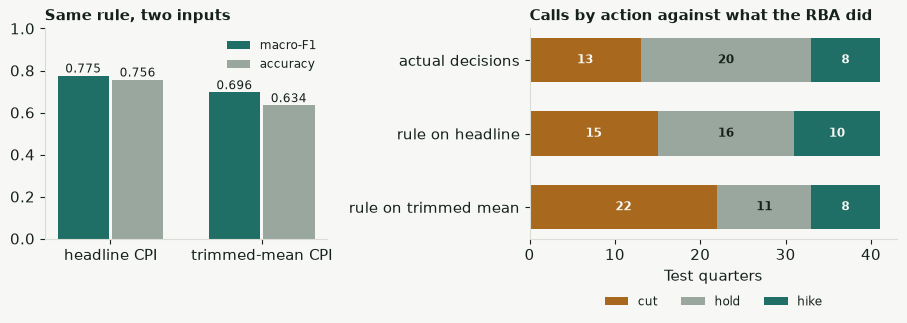

In [7]:
import re
from src.models import rba_classifier as rc

sample = rc.assemble_policy_sample()
test = sample.iloc[rc.DEFAULT_MIN_INITIAL_TRAIN_SIZE:]        # the report's selected split: 12 training quarters
scores, disagreements = rc.threshold_input_sensitivity(test)

# same 41 test quarters as the report: the headline rule must reproduce its reported threshold macro-F1
report = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text().splitlines()
reported = next(float(m.group(1)) for l in report if (m := re.match(r"^\| threshold\s+\|\s+([0-9.]+)\s+\|\s+[0-9.]+\s+\|\s+\d+\s+\|$", l)))
assert abs(scores.loc[0, "macro_f1"] - reported) < 5e-4, (scores.loc[0, "macro_f1"], reported)
gap = (test["headline_forecast"] - test["trimmed_mean_forecast"]).mean()
print(f"{len(test)} test quarters ({test['target_quarter'].iloc[0]} to {test['target_quarter'].iloc[-1]}); headline rule reproduces the "
      f"reported macro-F1 {reported:.3f}; the two inputs disagree in {disagreements} quarters; "
      f"the trimmed-mean forecast is {gap:.2f}pp lower on average")

actual = test["policy_action"].astype(str).value_counts().reindex(rc.ACTION_ORDER, fill_value=0)
mix = pd.DataFrame({"actual decisions": actual}).T
for _, r in scores.iterrows():
    mix.loc[f"rule on {r['threshold_input'].replace(' (reportable)', '')}"] = [r[f"predicted_{a}"] for a in rc.ACTION_ORDER]

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.5), gridspec_kw={"width_ratios": [1, 1.3]})
x = np.arange(2)
for j, (metric, label, colour) in enumerate((("macro_f1", "macro-F1", ACCENT), ("accuracy", "accuracy", MUTED))):
    bars = a.bar(x + (j - 0.5) * 0.36, scores[metric], width=0.34, color=colour, label=label)
    for rect, v in zip(bars, scores[metric]):
        a.text(rect.get_x() + rect.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center", fontsize=8.5)
a.set_xticks(x, ["headline CPI", "trimmed-mean CPI"])
a.set_ylim(0, 1)
a.set_title("Same rule, two inputs", loc="left", fontsize=10.5, fontweight="bold")
a.legend(frameon=False, fontsize=8.5, loc="upper right")
a.grid(False)

colours = {"cut": HIGHLIGHT, "hold": MUTED, "hike": ACCENT}
rows = mix.index[::-1]
left = np.zeros(len(rows))
for action in rc.ACTION_ORDER:
    vals = mix.loc[rows, action].to_numpy(dtype=float)
    b.barh(range(len(rows)), vals, left=left, color=colours[action], height=0.6, label=action)
    for y, (v, l) in enumerate(zip(vals, left)):
        b.text(l + v / 2, y, f"{int(v)}", ha="center", va="center", fontsize=8.8, color=PAPER if action != "hold" else INK, fontweight="bold")
    left += vals
b.set_yticks(range(len(rows)), rows)
b.set_xlabel("Test quarters")
b.set_title("Calls by action against what the RBA did", loc="left", fontsize=10.5, fontweight="bold")
b.legend(frameon=False, ncol=3, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.22))
b.grid(False)
fig.tight_layout()
plt.show()

The trimmed-mean input scores lower (macro-F1 0.696 against 0.775, accuracy 63% against 76%) and calls a different action in
15 of the 41 quarters. Most of the damage is over-called cuts: 22 predicted against 13 actual, where the headline rule
predicts 15. The trimmed-mean forecast sits 0.14pp lower than headline on average, which pushes more forecasts below the 2%
line. Two caveats. The check was run after the design was fixed and on the same test quarters as every other comparison, so
it is a sensitivity check, not a model-selection step. And the gap has no bootstrap interval, so on 41 quarters it should not
be read as settled. The same table is in `reports/rba_classifier_evaluation.md`.

```{tip}
The call and probabilities shown here come from the same pinned `reports/tableau/rba_action.csv` fallback the Streamlit app itself shows when the live API isn't reachable. To refresh against the live `/rba-action` endpoint instead, open **4.6 RBA Policy Classifier** in the [live demo](https://cpi-forecast-demo.streamlit.app/) and press **Refresh RBA action** (or run `streamlit run app/streamlit_app.py` locally).
```